# STAGE 11 — FAVOURABILITY-20 FIXED-RULE VISUAL COMPARISON

Применяем те же пять заранее заданных правил, заменяя только causal favourability window с 30 на 20 quote observations. Это locked-test descriptive diagnostics без winner selection, threshold optimization или forecasting retraining.

In [1]:
from pathlib import Path
import sys
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from src.favourability20_visual_comparison import RULES,plot_all,run_visual_comparison
run=run_visual_comparison(ROOT,make_plots=False)
print('Locked-test rows:',len(run['frame']))
print('Fixed rules:',len(RULES))
print('Forecasting retrained: NO; winner selected: NO')

Locked-test rows: 1375
Fixed rules: 5
Forecasting retrained: NO; winner selected: NO


## 1. Causal feature and descriptive metrics

Существующий `favourability_percentile_20` сверяется с независимым расчётом по строго предыдущим T−20…T−1. Current T исключён. Hit rate относительно GT_20 использует actual regret только как диагностическую label.

In [2]:
display(run['metrics'])

,corridor,rule,F,A,R,n_signals,signal_frequency,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,hit_rate
0,AMD_RUB,RULE_1_STRICT,0.90,0.002,0.002,23,0.083636,1.642857,0.0,9,0.304348
1,AMD_RUB,RULE_2,0.90,0.000,0.005,35,0.127273,2.500000,0.5,7,0.342857
2,AMD_RUB,RULE_3_BALANCED,0.85,0.000,0.005,36,0.130909,2.571429,0.5,7,0.333333
3,AMD_RUB,RULE_4_SOFT,0.85,NaN,0.005,63,0.229091,4.500000,1.0,7,0.412698
4,AMD_RUB,RULE_5_BROAD,0.80,NaN,0.010,66,0.240000,4.714286,1.0,7,0.393939
5,KGS_RUB,RULE_1_STRICT,0.90,0.002,0.002,21,0.076364,1.500000,0.0,8,0.238095
6,KGS_RUB,RULE_2,0.90,0.000,0.005,40,0.145455,2.857143,0.5,7,0.275000
7,KGS_RUB,RULE_3_BALANCED,0.85,0.000,0.005,41,0.149091,2.928571,0.5,7,0.268293
8,KGS_RUB,RULE_4_SOFT,0.85,NaN,0.005,71,0.258182,5.071429,1.5,7,0.366197
9,KGS_RUB,RULE_5_BROAD,0.80,NaN,0.010,77,0.280000,5.500000,2.5,6,0.337662


## 2. 25 individual plots and 5 stacked comparisons

Красные точки — signal_rule_X. Все пять stacked panels внутри corridor имеют одинаковые x/y limits. Lower rate = better.

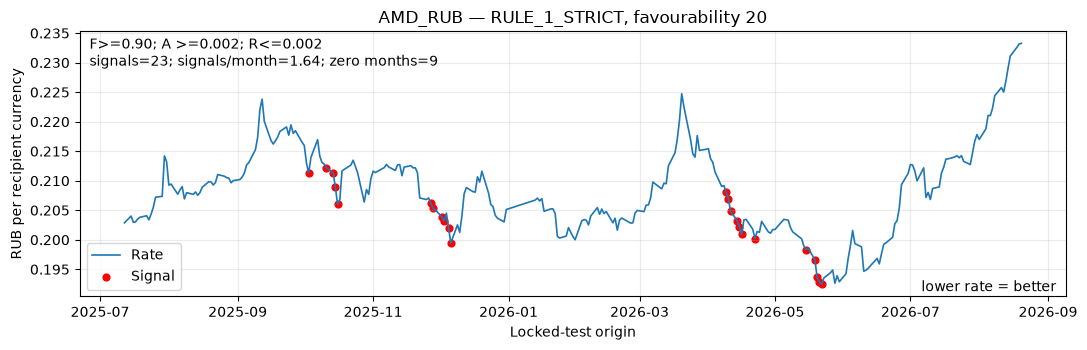

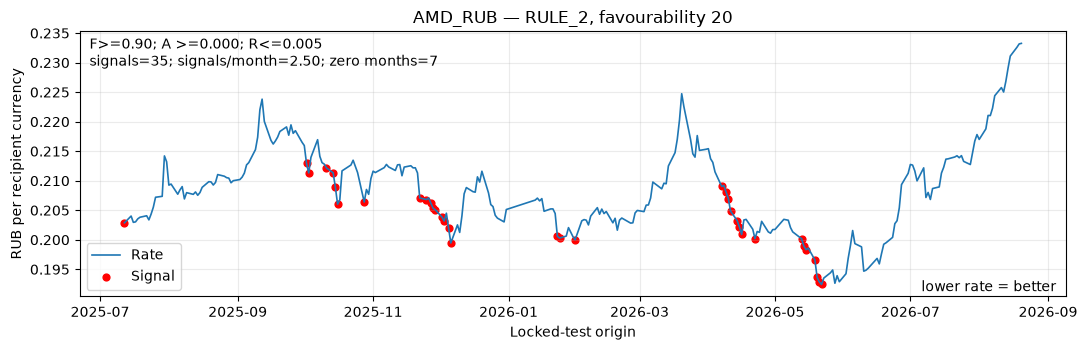

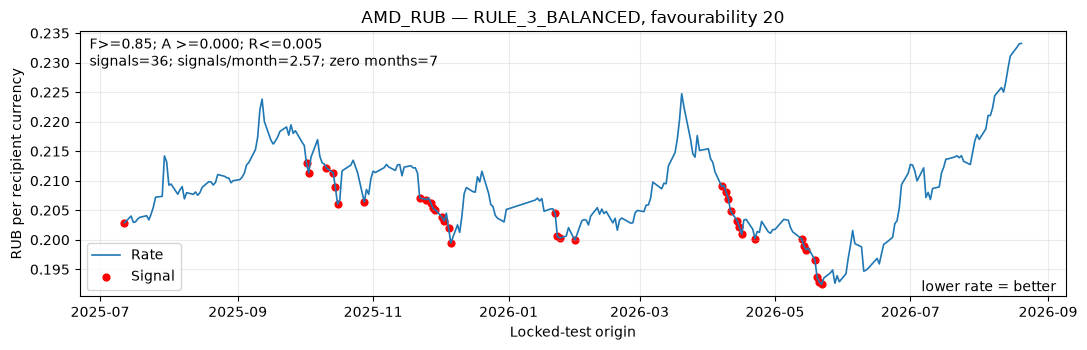

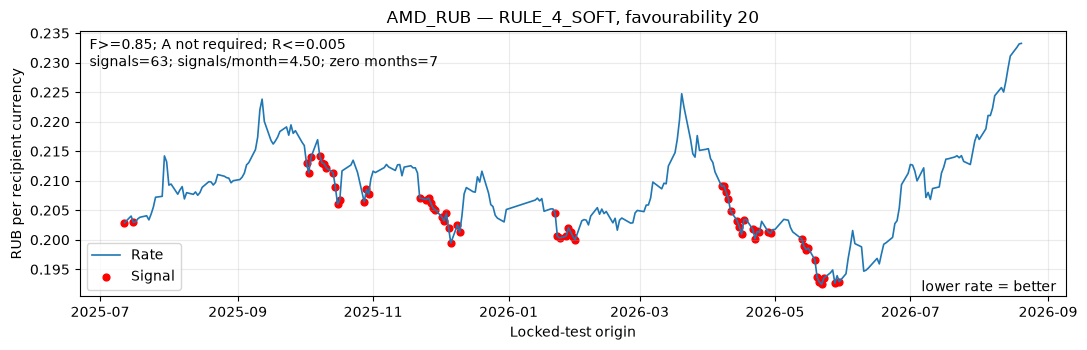

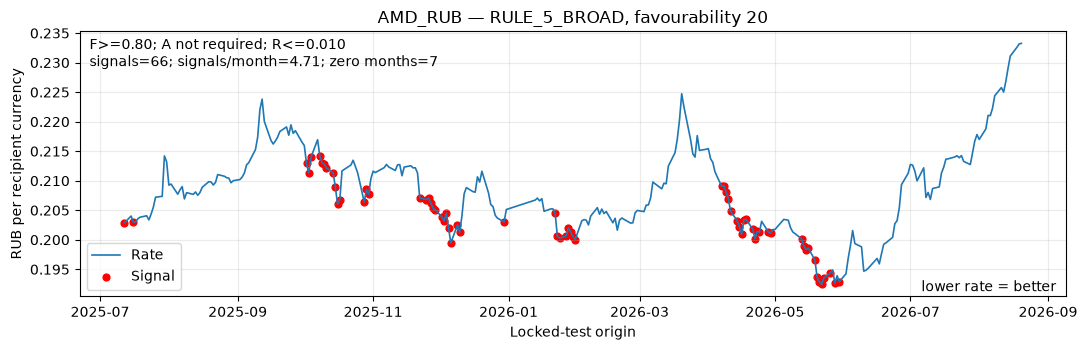

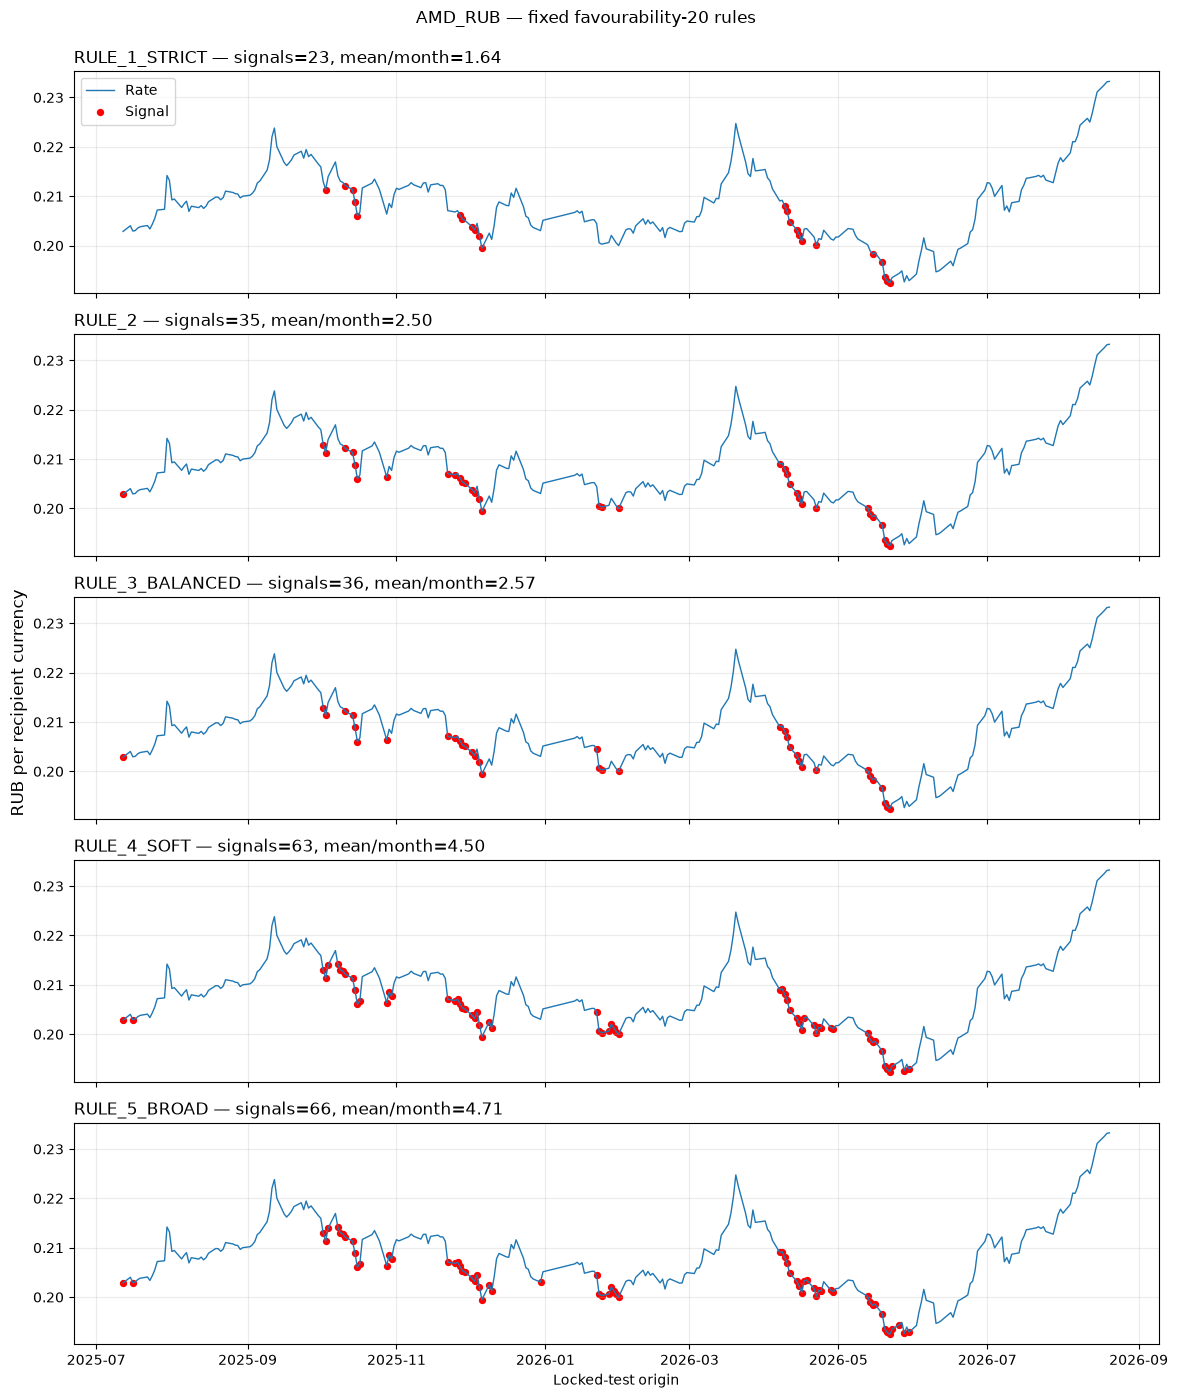

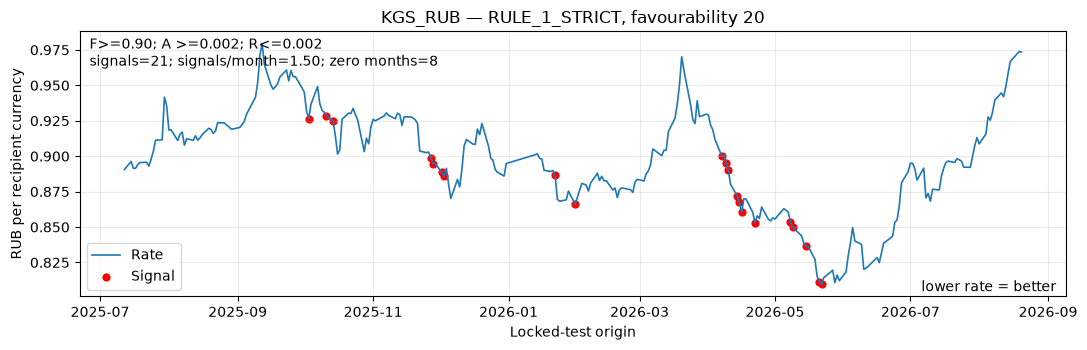

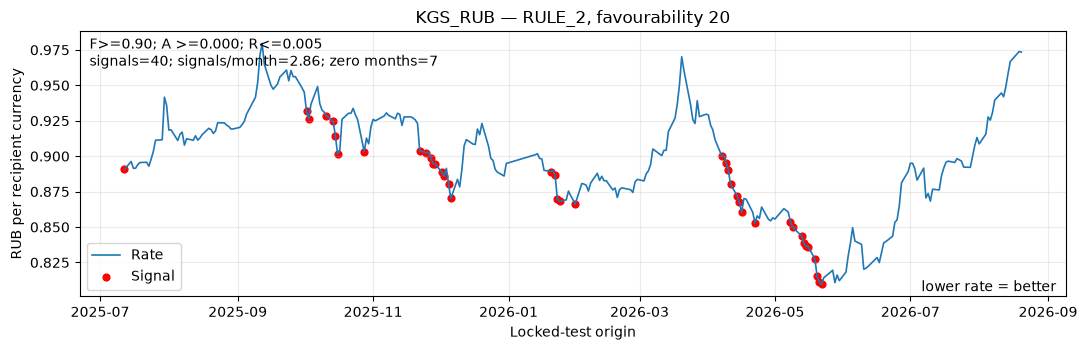

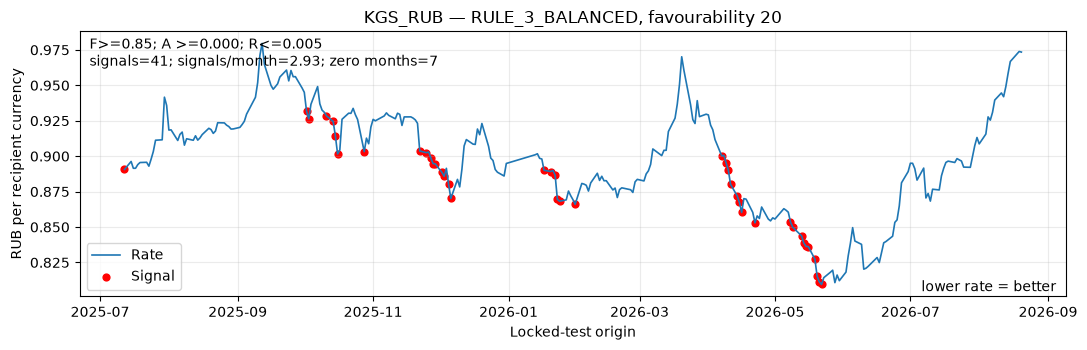

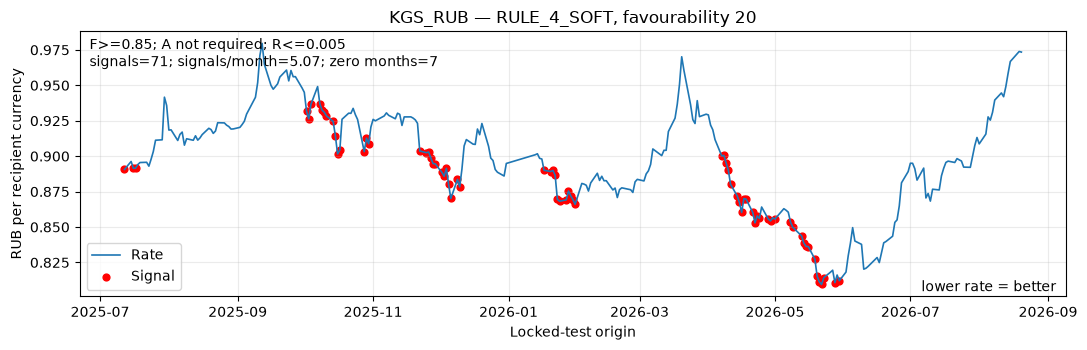

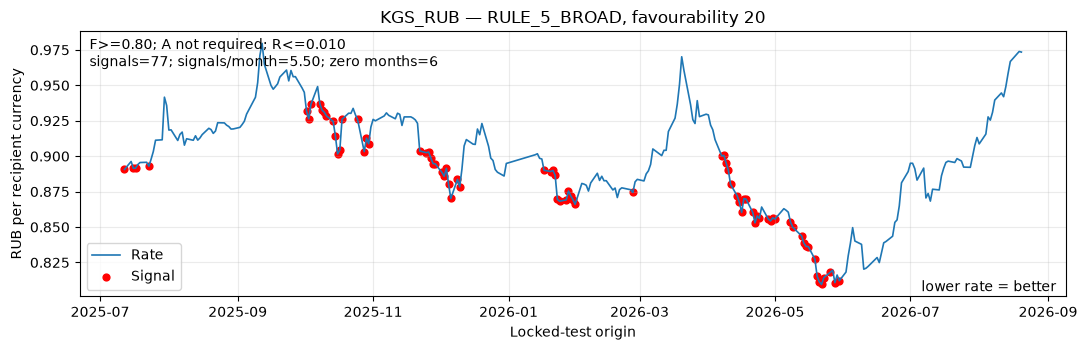

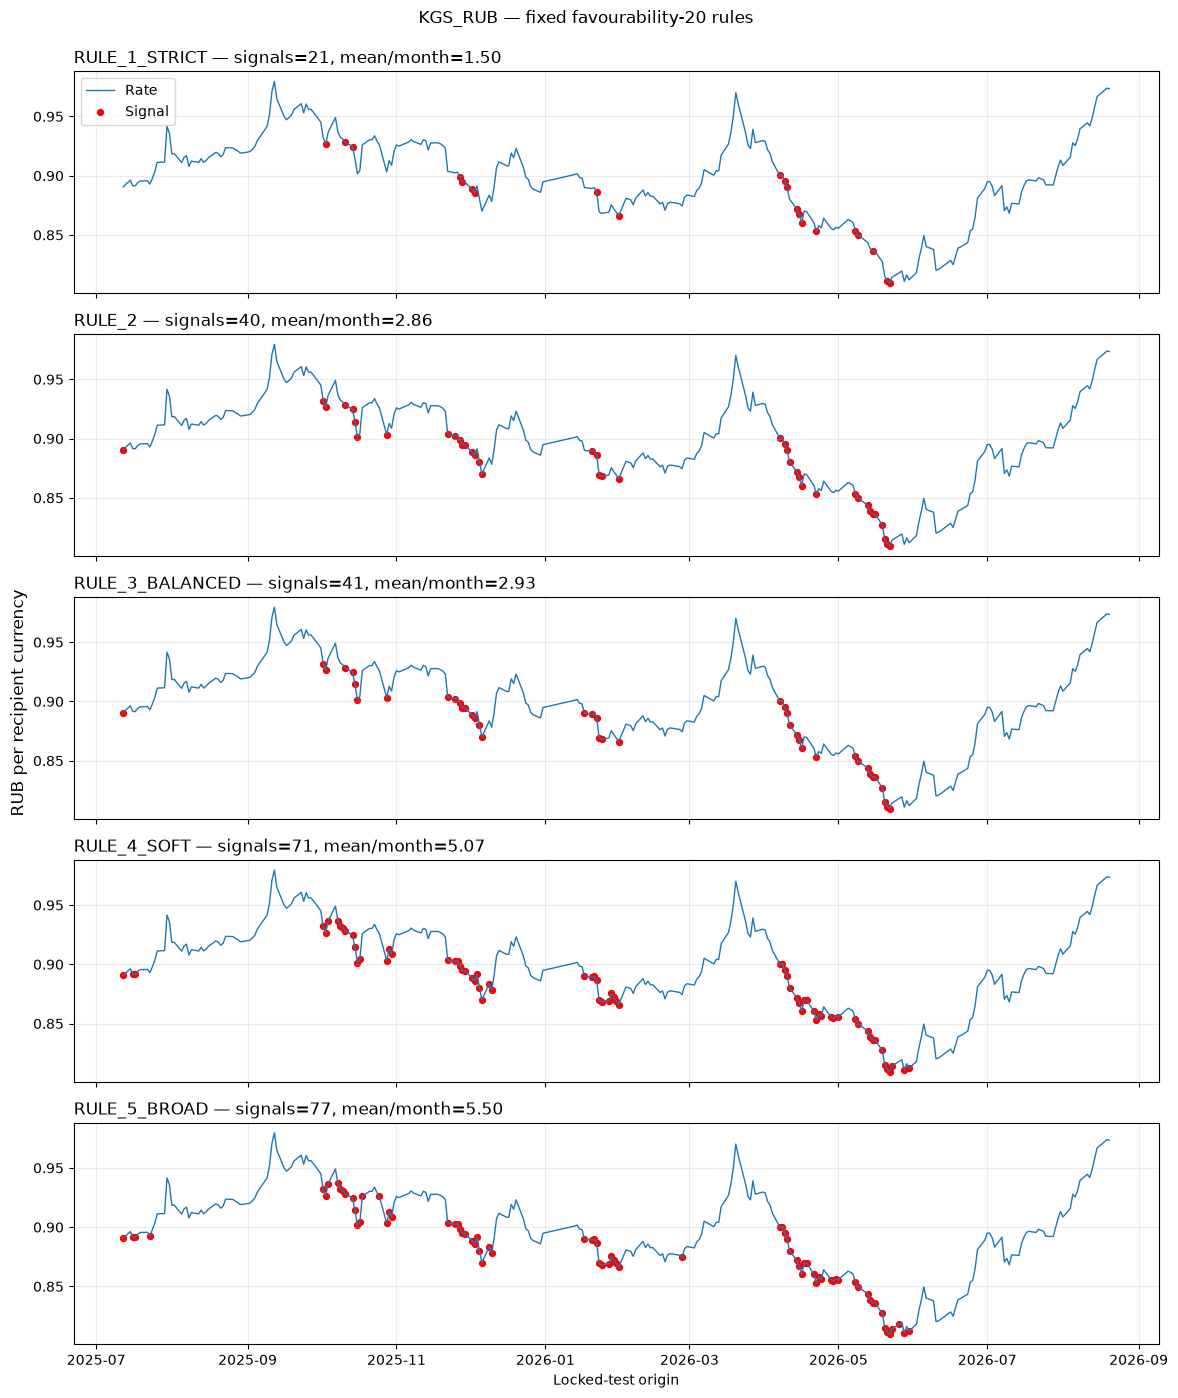

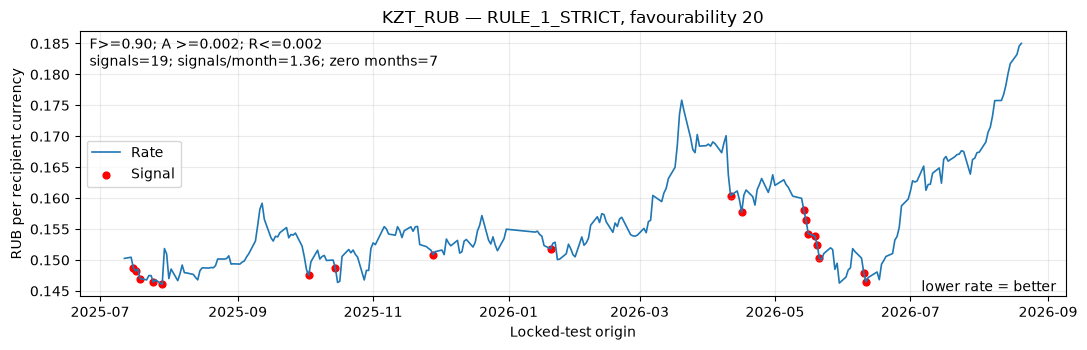

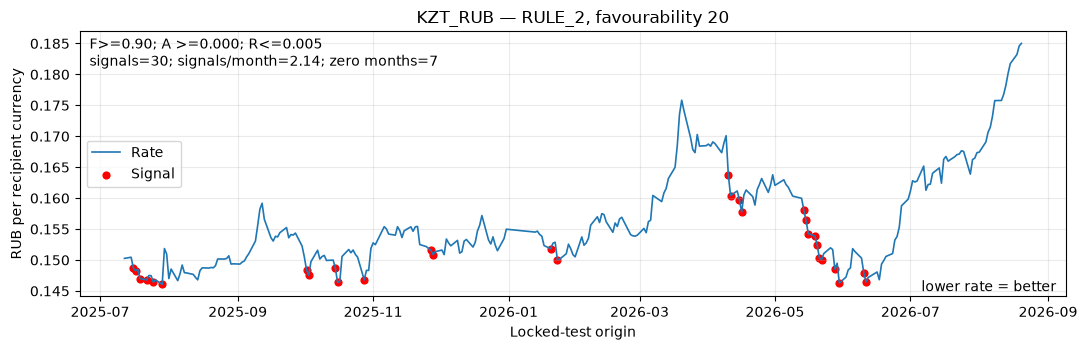

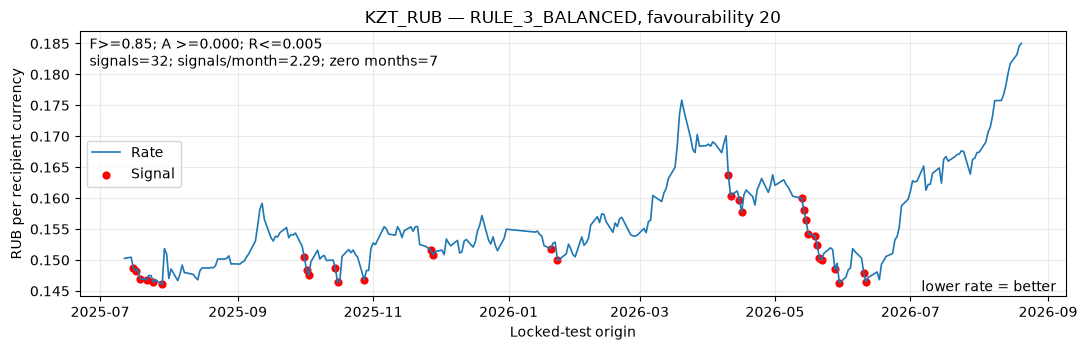

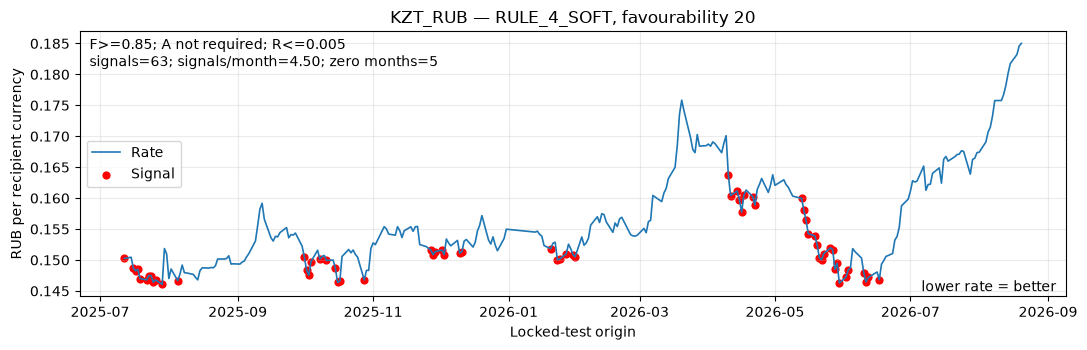

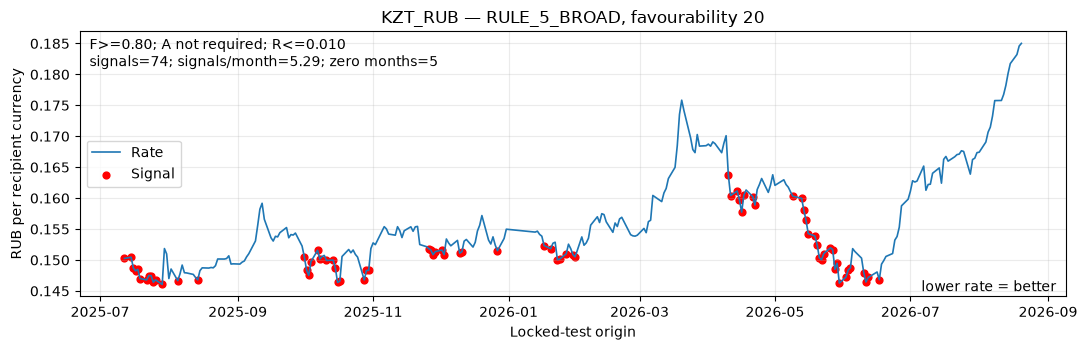

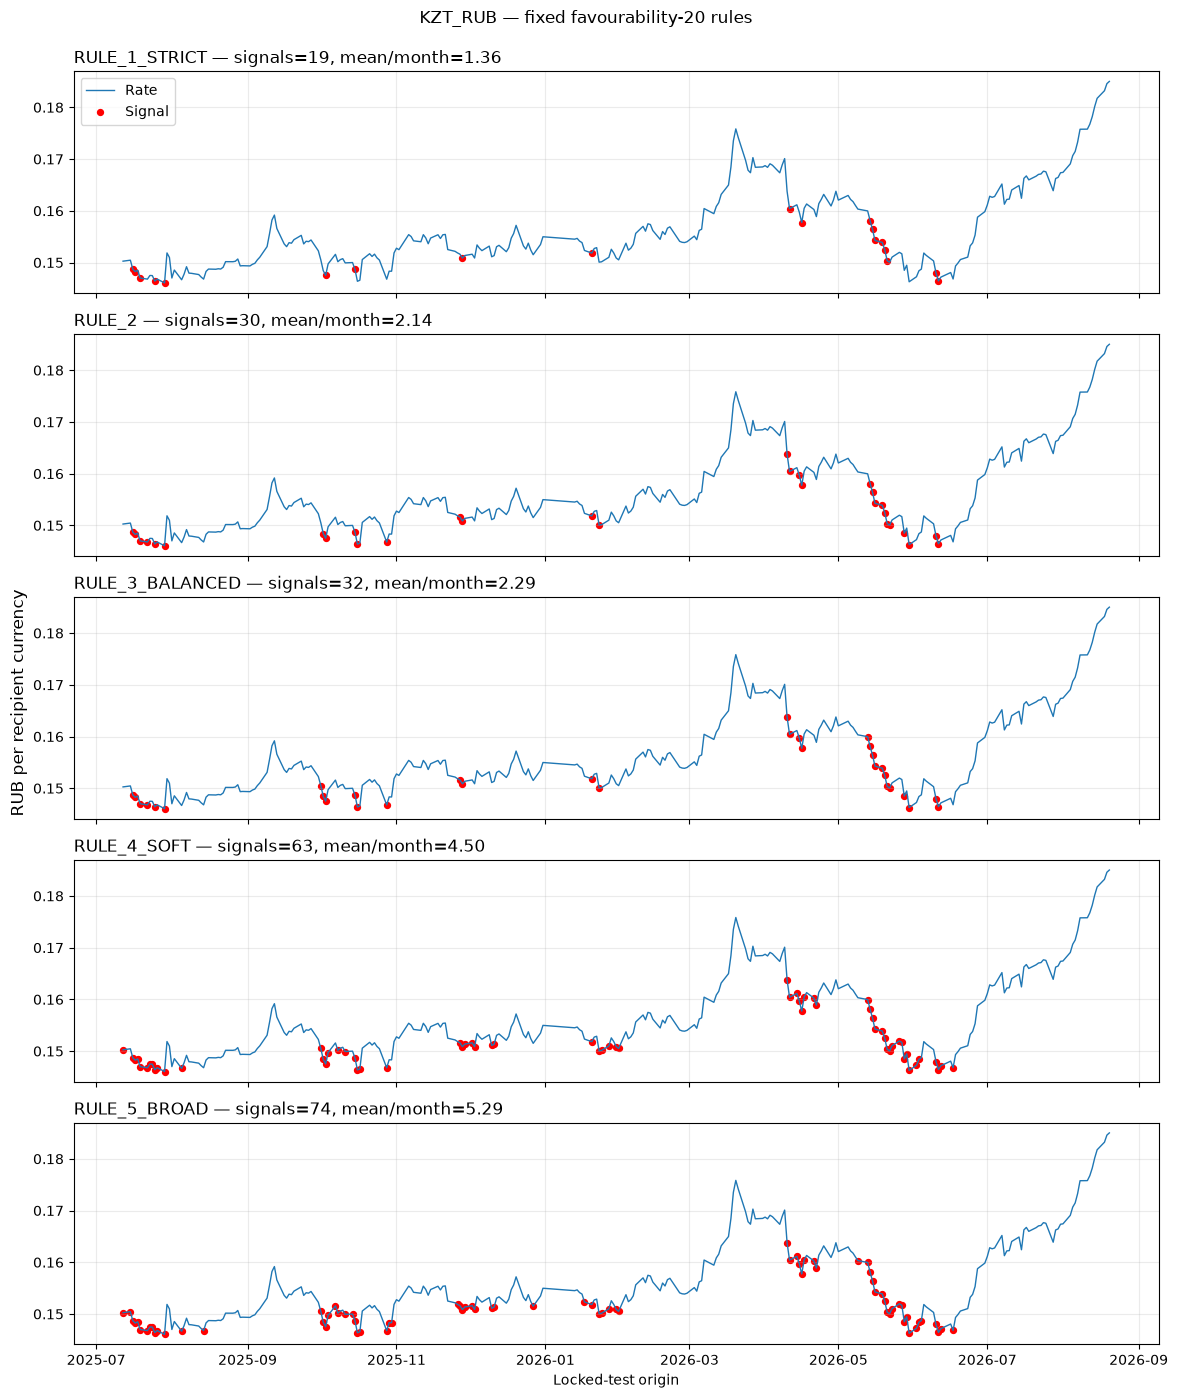

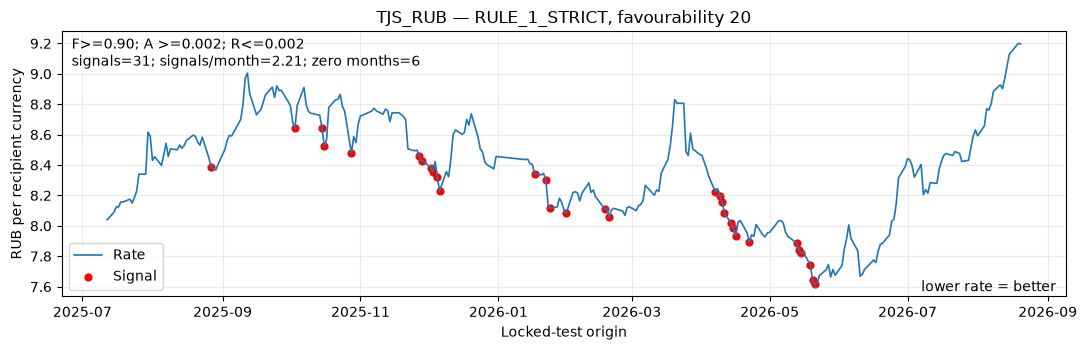

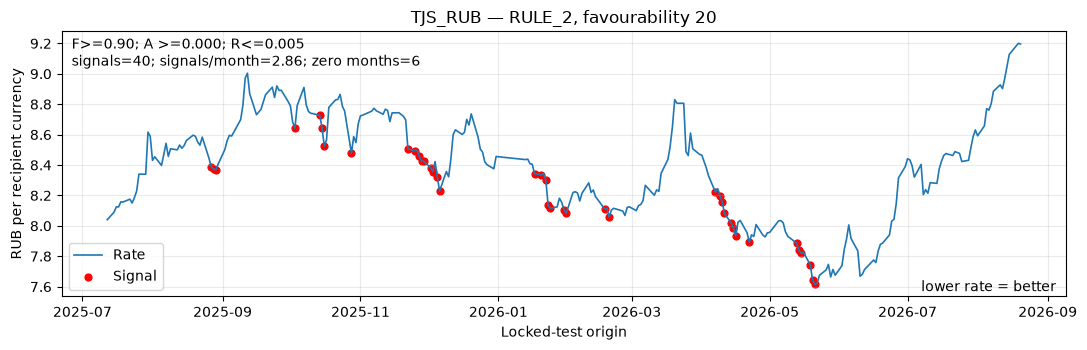

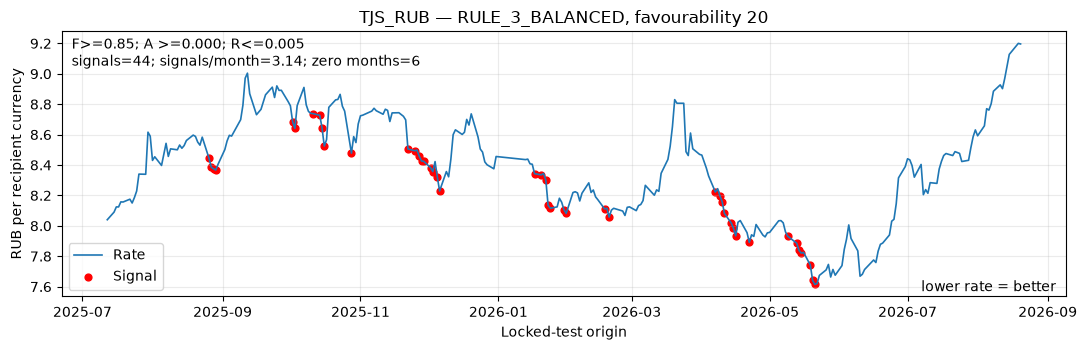

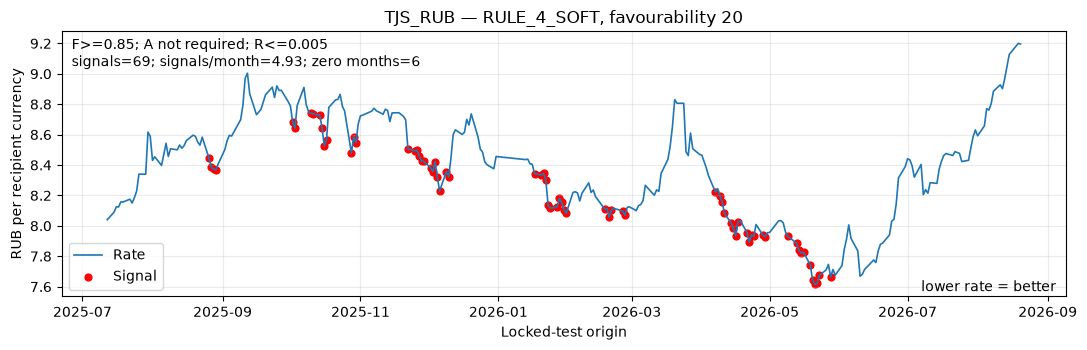

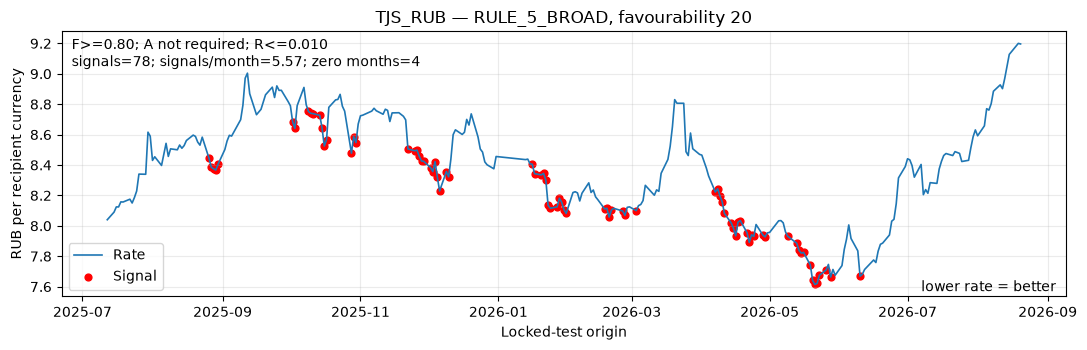

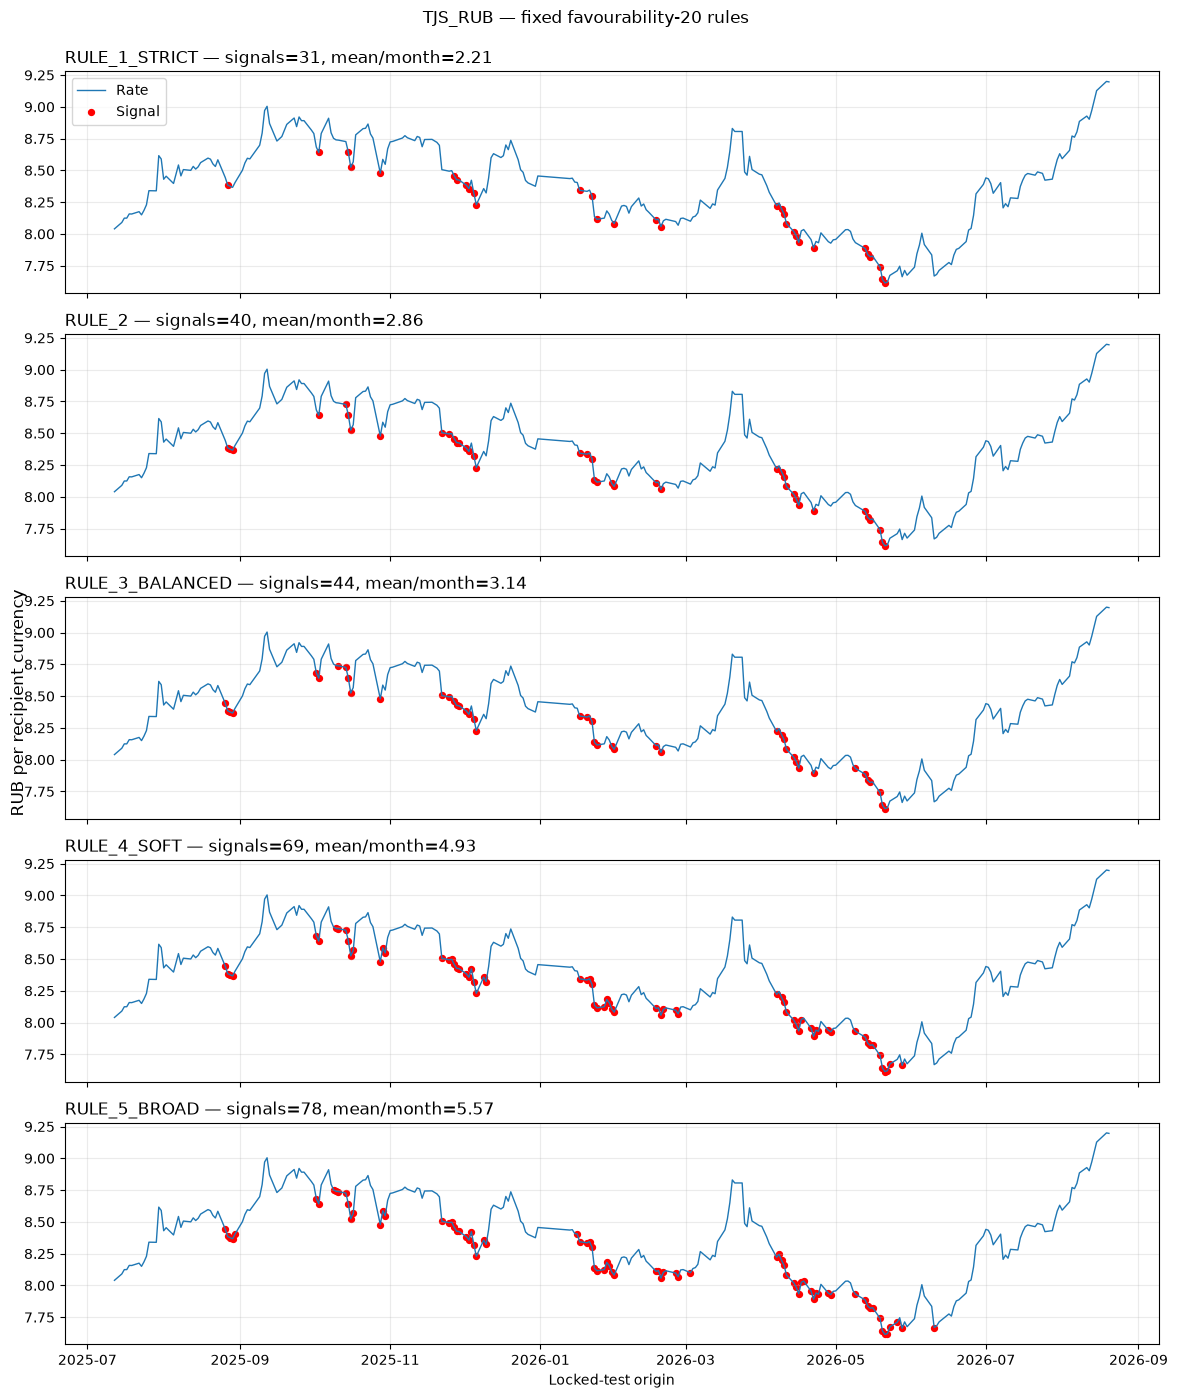

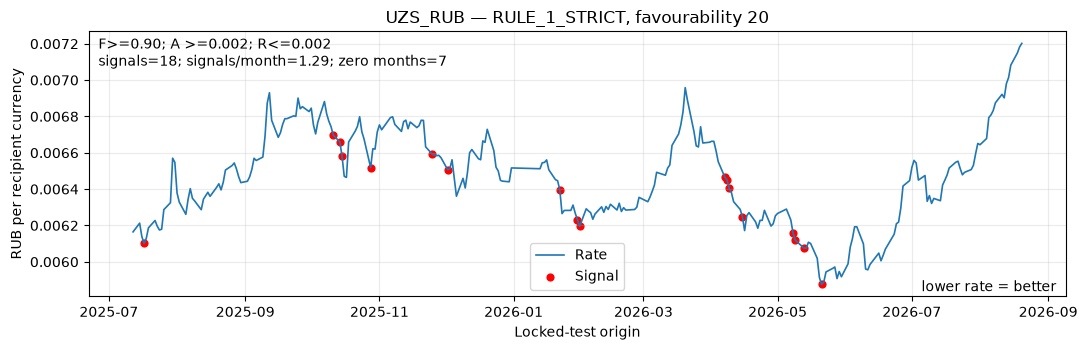

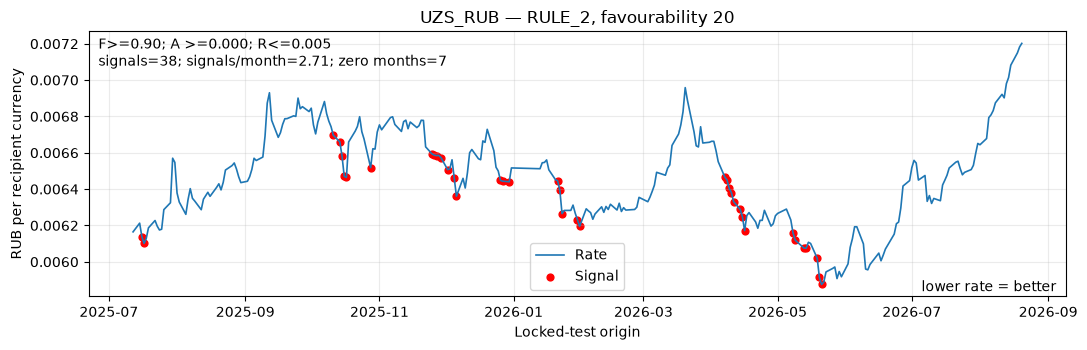

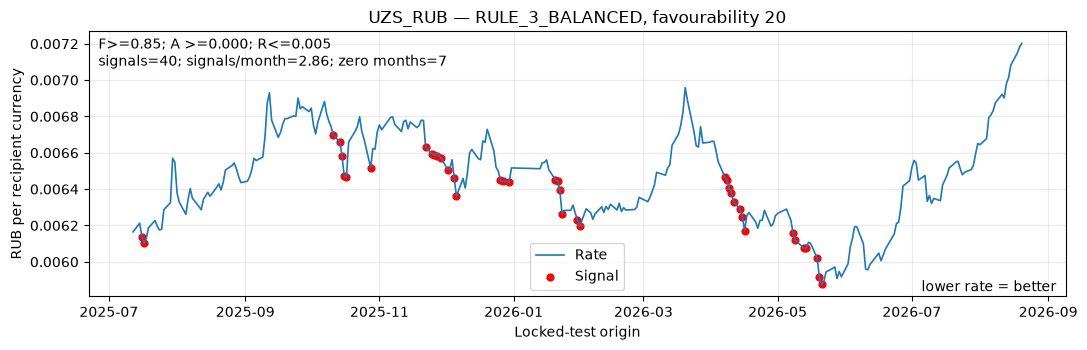

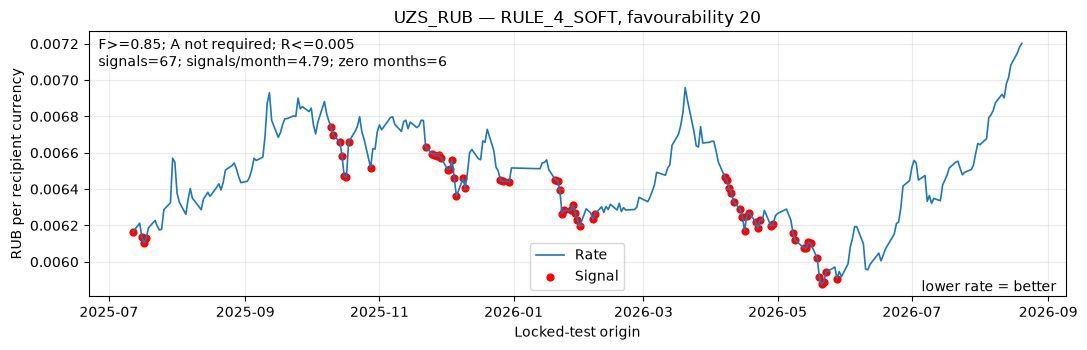

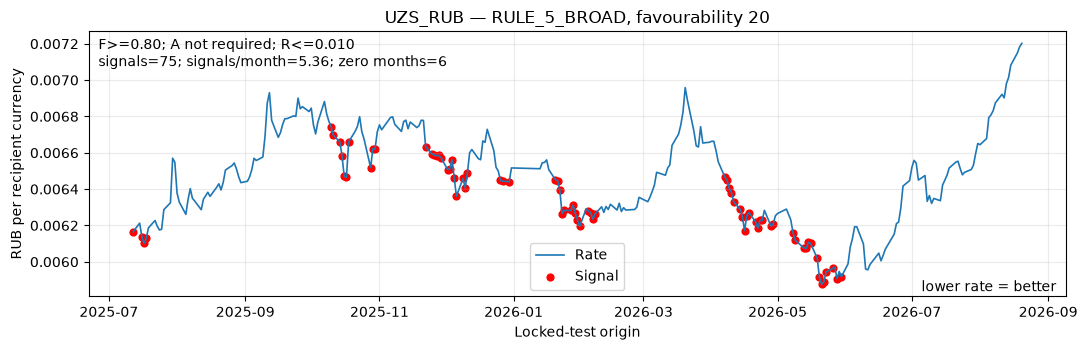

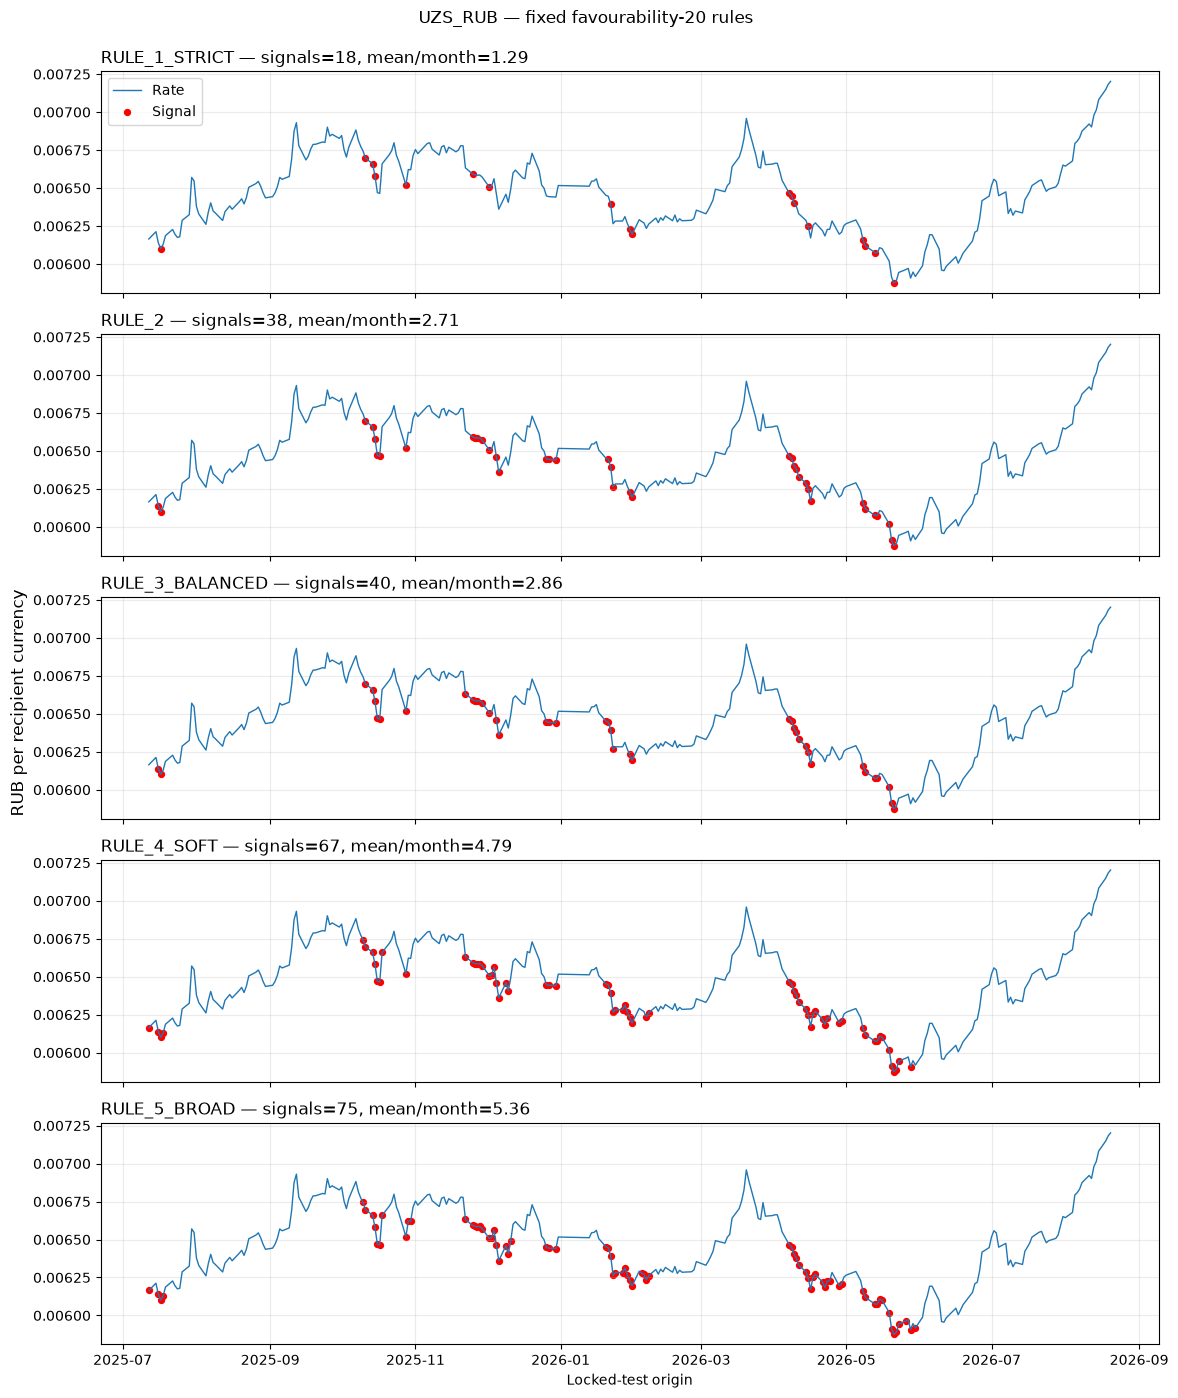

In [3]:
plot_all(run['frame'],run['metrics'],ROOT/'reports/figures/favourability20_rule_comparison')

## 3. Compact descriptive 20 vs 30 comparison

Сравнение не используется для выбора winner.

In [4]:
display(run['comparison'])

,corridor,rule,F,A,R,n_signals_20,signal_frequency_20,mean_signals_per_month_20,median_signals_per_month_20,months_with_zero_signals_20,hit_rate_20,n_signals_30,signal_frequency_30,mean_signals_per_month_30,median_signals_per_month_30,months_with_zero_signals_30,hit_rate_30
0,AMD_RUB,RULE_1_STRICT,0.90,0.002,0.002,23,0.083636,1.642857,0.0,9,0.304348,18,0.065455,1.285714,0.0,9,0.333333
1,AMD_RUB,RULE_2,0.90,0.000,0.005,35,0.127273,2.500000,0.5,7,0.342857,28,0.101818,2.000000,0.5,7,0.392857
2,AMD_RUB,RULE_3_BALANCED,0.85,0.000,0.005,36,0.130909,2.571429,0.5,7,0.333333,30,0.109091,2.142857,0.5,7,0.400000
3,AMD_RUB,RULE_4_SOFT,0.85,NaN,0.005,63,0.229091,4.500000,1.0,7,0.412698,52,0.189091,3.714286,1.0,7,0.500000
4,AMD_RUB,RULE_5_BROAD,0.80,NaN,0.010,66,0.240000,4.714286,1.0,7,0.393939,68,0.247273,4.857143,2.0,6,0.382353
5,KGS_RUB,RULE_1_STRICT,0.90,0.002,0.002,21,0.076364,1.500000,0.0,8,0.238095,15,0.054545,1.071429,0.0,8,0.266667
6,KGS_RUB,RULE_2,0.90,0.000,0.005,40,0.145455,2.857143,0.5,7,0.275000,32,0.116364,2.285714,0.5,7,0.312500
7,KGS_RUB,RULE_3_BALANCED,0.85,0.000,0.005,41,0.149091,2.928571,0.5,7,0.268293,33,0.120000,2.357143,0.5,7,0.303030
8,KGS_RUB,RULE_4_SOFT,0.85,NaN,0.005,71,0.258182,5.071429,1.5,7,0.366197,61,0.221818,4.357143,2.0,7,0.459016
9,KGS_RUB,RULE_5_BROAD,0.80,NaN,0.010,77,0.280000,5.500000,2.5,6,0.337662,76,0.276364,5.428571,4.0,6,0.368421


## 4. Leakage check

In [5]:
display(run['leakage'])
check='PASS' if run['leakage'].passed.all() else 'FAIL'
print('FAVOURABILITY 20 VISUAL CHECK:',check)

,check,passed
0,favourability_20 uses T-20...T-1 only,True
1,current T excluded,True
2,signals use approved live fields only,True
3,actual regret diagnostic only,True
4,no actual future rate in signals,True
5,no winner or optimization,True


FAVOURABILITY 20 VISUAL CHECK: PASS


## 5. Descriptive final summary

Результаты показываются по corridor × RULE_1…RULE_5 без ранжирования и автоматической рекомендации.

In [6]:
display(run['metrics'][['corridor','rule','n_signals','mean_signals_per_month','months_with_zero_signals','hit_rate']])
print('No best rule selected. No automatic winner recommendation.')
print('Output:',run['csv_path'].relative_to(ROOT))
print('Report:',run['report_path'].relative_to(ROOT))

,corridor,rule,n_signals,mean_signals_per_month,months_with_zero_signals,hit_rate
0,AMD_RUB,RULE_1_STRICT,23,1.642857,9,0.304348
1,AMD_RUB,RULE_2,35,2.500000,7,0.342857
2,AMD_RUB,RULE_3_BALANCED,36,2.571429,7,0.333333
3,AMD_RUB,RULE_4_SOFT,63,4.500000,7,0.412698
4,AMD_RUB,RULE_5_BROAD,66,4.714286,7,0.393939
5,KGS_RUB,RULE_1_STRICT,21,1.500000,8,0.238095
6,KGS_RUB,RULE_2,40,2.857143,7,0.275000
7,KGS_RUB,RULE_3_BALANCED,41,2.928571,7,0.268293
8,KGS_RUB,RULE_4_SOFT,71,5.071429,7,0.366197
9,KGS_RUB,RULE_5_BROAD,77,5.500000,6,0.337662


No best rule selected. No automatic winner recommendation.
Output: reports\favourability20_rule_visual_comparison.csv
Report: reports\favourability20_rule_visual_report.md
